In this notebook, we would like to test the differences among greedy, unique greedy assignment and hungarian algorithm with cost function called cosine similairty which is one of the quality metric of real data and synthetic data  

# 1. Data loading and preparation

In [1]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')

data = pd.read_csv('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Banking.csv')

# droping diagnosis column which is not the main focus here

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32950 non-null  int64 
 1   job          32950 non-null  object
 2   marital      32950 non-null  object
 3   education    32950 non-null  object
 4   default      32950 non-null  object
 5   housing      32950 non-null  object
 6   loan         32950 non-null  object
 7   contact      32950 non-null  object
 8   month        32950 non-null  object
 9   day_of_week  32950 non-null  object
 10  duration     32950 non-null  int64 
 11  campaign     32950 non-null  int64 
 12  pdays        32950 non-null  int64 
 13  previous     32950 non-null  int64 
 14  poutcome     32950 non-null  object
 15  y            32950 non-null  object
dtypes: int64(5), object(11)
memory usage: 4.0+ MB


In [2]:
data = data.iloc[:10000].copy()
print("Training data shape:", data.shape)

Training data shape: (10000, 16)


In [3]:
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

Data shape: (10000, 16)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [4]:
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

models = {
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

for name, model in models.items():
    print(f"Fitting {name} on 10,000 rows...")
    model.fit(data)

print("All models fitted on reduced data!")

Fitting GaussianCopula on 10,000 rows...
Fitting CTGAN on 10,000 rows...
Fitting CopulaGAN on 10,000 rows...
Fitting TVAE on 10,000 rows...
All models fitted on reduced data!


In [5]:
synthetic_data = {}

for name, model in models.items():
    print(f"Sampling from {name}...")
    synthetic_data[name] = model.sample(num_rows=len(data))

Sampling from GaussianCopula...
Sampling from CTGAN...
Sampling from CopulaGAN...
Sampling from TVAE...


In [6]:
import numpy as np
import pandas as pd

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
real_matrix = data[num_cols].to_numpy(dtype=float)
def normalize_rows(x, eps=1e-12):
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / (norm + eps)

In [9]:
# 1️⃣ Select numeric columns only
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# 2️⃣ Use first 10,000 rows
N = 10000

real_matrix = data[num_cols].iloc[:N].to_numpy(dtype=float)

# 3️⃣ Row-wise normalization function
def normalize_rows(x, eps=1e-12):
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / (norm + eps)

# Normalize real data once
real_matrix = normalize_rows(real_matrix)

# 4️⃣ Cosine similarity computation
cosine_dfs = {}

for model_name, synth_df in synthetic_data.items():

    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = (
        synth_df[num_cols]
        .iloc[:N]
        .to_numpy(dtype=float)
    )

    synth_matrix = normalize_rows(synth_matrix)

    # Cosine similarity matrix
    cosine_matrix = real_matrix @ synth_matrix.T

    # 5️⃣ Keep a readable subset (e.g. 100×100)
    view_n = 100

    cosine_df = pd.DataFrame(
        cosine_matrix[:view_n, :view_n],
        index=[f"R{i+1}" for i in range(view_n)],
        columns=[f"S{j+1}" for j in range(view_n)]
    )

    cosine_dfs[model_name] = cosine_df

    print(cosine_df, "\n")

Building cosine similarity DataFrame for GaussianCopula...
            S1        S2        S3        S4        S5        S6        S7  \
R1    0.997260  0.996037  0.981057  0.999989  0.785008  0.995279  0.819001   
R2    0.998699  0.993775  0.985508  0.999559  0.770067  0.997330  0.804809   
R3    0.761966  0.855925  0.678462  0.808851  0.998990  0.746832  0.999801   
R4    0.999504  0.981721  0.995901  0.994313  0.716682  0.999967  0.754898   
R5    0.979361  0.998844  0.947812  0.991870  0.858204  0.974405  0.886233   
...        ...       ...       ...       ...       ...       ...       ...   
R96   0.841260  0.917234  0.770242  0.879744  0.985424  0.828653  0.993312   
R97   0.999973  0.987501  0.992305  0.997327  0.739551  0.999649  0.776447   
R98   0.991376  0.957289  0.999783  0.978631  0.642326  0.994087  0.684979   
R99   0.994965  0.966142  0.999776  0.984520  0.666508  0.997042  0.707455   
R100  0.994800  0.998120  0.975723  0.999432  0.801214  0.992327  0.833405   

    

In [10]:
avg_cosine_scores = {}

for model_name, synth_df in synthetic_data.items():

    synth_matrix = (
        synth_df[num_cols]
        .iloc[:N]
        .to_numpy(dtype=float)
    )

    synth_matrix = normalize_rows(synth_matrix)

    # 🔹 Row-wise cosine similarity (real_i vs synthetic_i)
    cosine_scores = np.sum(real_matrix * synth_matrix, axis=1)

    avg_cosine_scores[model_name] = cosine_scores.mean()

# Convert to DataFrame for readability
avg_cosine_df = pd.DataFrame.from_dict(
    avg_cosine_scores,
    orient='index',
    columns=['average_cosine_similarity']
)

print(avg_cosine_df)

                average_cosine_similarity
GaussianCopula                   0.931385
CTGAN                            0.885661
CopulaGAN                        0.876139
TVAE                             0.926088


# 2. Greedy assignment

In [11]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

# -------------------------------------------------
# Helper: row normalization for cosine similarity
# -------------------------------------------------
def normalize_rows(X, eps=1e-12):
    return X / (norm(X, axis=1, keepdims=True) + eps)

# -------------------------------------------------
# Greedy one-to-one cosine assignment
# -------------------------------------------------
def greedy_cosine_assignment(
    real_data: pd.DataFrame,
    synthetic_data: pd.DataFrame,
    max_rows: int = 10_000
):
    # Use numeric columns only
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()

    # Limit rows for cost control
    real_df = real_data[num_cols].iloc[:max_rows]
    synth_df = synthetic_data[num_cols].iloc[:max_rows]

    # Convert to normalized matrices
    R = normalize_rows(real_df.to_numpy(dtype=float))
    S = normalize_rows(synth_df.to_numpy(dtype=float))

    n_real, n_synth = R.shape[0], S.shape[0]

    used_synth = np.zeros(n_synth, dtype=bool)
    assignments = np.empty(n_real, dtype=int)
    similarities = np.empty(n_real, dtype=float)

    # Greedy matching
    for i in range(n_real):
        sims = R[i] @ S.T
        sims[used_synth] = -np.inf  # block already-used synthetic rows

        best_j = np.argmax(sims)
        assignments[i] = best_j
        similarities[i] = sims[best_j]
        used_synth[best_j] = True

    return assignments, similarities

# -------------------------------------------------
# Run greedy cosine assignment for ALL models
# (models already fitted, synthetic_data already exists)
# -------------------------------------------------
results = {}

# Use the same 10,000 rows as model training
data_eval = data.iloc[:10_000].copy()

for model_name, synth_df in synthetic_data.items():

    print(f"\n==============================")
    print(f"{model_name}: Greedy Cosine Assignment")
    print(f"==============================")

    best_idx, best_sim = greedy_cosine_assignment(
        real_data=data_eval,
        synthetic_data=synth_df,
        max_rows=10_000
    )

    results[model_name] = {
        "best_indices": best_idx,
        "best_similarities": best_sim,
        "average_similarity": best_sim.mean(),
    }

    print(f"Average cosine similarity ({model_name}): {best_sim.mean():.4f}")


GaussianCopula: Greedy Cosine Assignment
Average cosine similarity (GaussianCopula): 0.9853

CTGAN: Greedy Cosine Assignment
Average cosine similarity (CTGAN): 0.9675

CopulaGAN: Greedy Cosine Assignment
Average cosine similarity (CopulaGAN): 0.9574

TVAE: Greedy Cosine Assignment
Average cosine similarity (TVAE): 0.9832


# 4. Hungarian algorithm

                num_cols=None):
    """
    Perform optimal 1-to-1 matching between real and synthetic samples
    using the Hungarian algorithm on (1 - cosine_similarity) as cost.

    Returns
    -------
    row_ind : np.ndarray
        Indices of real samples in the matching (0-based).
    col_ind : np.ndarray
        Indices of synthetic samples matched to each real (0-based).
    selected_similarities : np.ndarray
        Cosine similarity values for each matched pair.
    avg_similarity : float
        Average cosine similarity over the matched pairs.
    cos_sim : np.ndarray
        Full cosine similarity matrix (N_real x N_synth).
    """

In [13]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def normalize_rows(X, eps=1e-12):
    return X / (norm(X, axis=1, keepdims=True) + eps)

def cosine_similarity_matrix(real_df, synth_df, num_cols):
    R = normalize_rows(real_df[num_cols].to_numpy(dtype=float))
    S = normalize_rows(synth_df[num_cols].to_numpy(dtype=float))
    return R @ S.T


# -------------------------------------------------
# Hungarian (optimal) cosine matching
# -------------------------------------------------
def hungarian_match(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None,
    max_rows: int = 10_000
):
    # Numeric columns only
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    # Restrict rows for feasibility
    real_df = real_df[num_cols].iloc[:max_rows]
    synth_df = synth_df[num_cols].iloc[:max_rows]

    # Cosine similarity
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)

    # Maximize similarity → minimize cost
    cost_matrix = 1.0 - cos_sim

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    selected_similarities = cos_sim[row_ind, col_ind]

    avg_similarity = float(selected_similarities.mean())

    return row_ind, col_ind, selected_similarities, avg_similarity


# -------------------------------------------------
# Run Hungarian assessment for ALL models
# (models already trained, synthetic_data already exists)
# -------------------------------------------------
results = {}

data_eval = data.iloc[:10_000].copy()

for model_name, synth_df in synthetic_data.items():

    print(f"\n==============================")
    print(f"{model_name}: Hungarian cosine assessment")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim = hungarian_match(
        real_df=data_eval,
        synth_df=synth_df,
        max_rows=10_000
    )

    results[model_name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
    }

    print(f"Average cosine similarity (Hungarian): {avg_sim:.4f}\n")

    # Show first 10 matched pairs
    for k in range(min(10, len(row_ind))):
        print(
            f"R{row_ind[k]+1} ↔ S{col_ind[k]+1}   "
            f"cosine similarity = {sims[k]:.4f}"
        )


GaussianCopula: Hungarian cosine assessment
Average cosine similarity (Hungarian): 0.9912

R1 ↔ S697   cosine similarity = 0.9978
R2 ↔ S1218   cosine similarity = 0.9984
R3 ↔ S6072   cosine similarity = 0.9917
R4 ↔ S414   cosine similarity = 0.9998
R5 ↔ S5786   cosine similarity = 0.9965
R6 ↔ S5957   cosine similarity = 0.9977
R7 ↔ S9733   cosine similarity = 0.9975
R8 ↔ S6940   cosine similarity = 0.9997
R9 ↔ S2294   cosine similarity = 0.9989
R10 ↔ S6792   cosine similarity = 0.9981

CTGAN: Hungarian cosine assessment
Average cosine similarity (Hungarian): 0.9875

R1 ↔ S889   cosine similarity = 0.9995
R2 ↔ S432   cosine similarity = 0.9996
R3 ↔ S9265   cosine similarity = 0.7832
R4 ↔ S9395   cosine similarity = 0.9998
R5 ↔ S8594   cosine similarity = 0.9993
R6 ↔ S672   cosine similarity = 0.9993
R7 ↔ S6488   cosine similarity = 0.9998
R8 ↔ S4940   cosine similarity = 0.9998
R9 ↔ S1708   cosine similarity = 0.9869
R10 ↔ S171   cosine similarity = 0.9977

CopulaGAN: Hungarian cosine 

## 4.1. Scenario 1

This is the condition where we consider the scenario where |R| = |S|. It is possible that the number of synthetic samples is significantly larger than the real ones, i.e., |R| > |S|.

Lets imagine

Number of real samples = N
Number of synthetic samples = 3N

In such a case, we will:

- Use the Hungarian algorithm to select the best N synthetic samples (Option 1).
- For the remaining 4N synthetic samples, compute their closeness to the real data (Option 2).
- Optionally, filter out synthetic samples that are "too close" to any real sample (for privacy).

In [14]:
gc_model   = GaussianCopulaSynthesizer(metadata=metadata)
ctgan_model = CTGANSynthesizer(metadata=metadata)
cop_model   = CopulaGANSynthesizer(metadata=metadata)
tvae_model  = TVAESynthesizer(metadata=metadata)

# Fit models
gc_model.fit(data)
ctgan_model.fit(data)
cop_model.fit(data)
tvae_model.fit(data)

# Sample 15000 rows from each model
synthetic_data_gaussian_copula = gc_model.sample(num_rows=15000)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=15000)
synthetic_data_copulagan       = cop_model.sample(num_rows=15000)
synthetic_data_tvae            = tvae_model.sample(num_rows=15000)

# Show structure
# print("\nGaussianCopula synthetic data:")
# synthetic_data_gaussian_copula.info()

# print("\nCTGAN synthetic data:")
# synthetic_data_ctgan.info()

# print("\nCopulaGAN synthetic data:")
# synthetic_data_copulagan.info()

# print("\nTVAE synthetic data:")
# synthetic_data_tvae.info()

In [15]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

# -------------------------------------------------
# Cosine similarity helpers (numeric features only)
# -------------------------------------------------
def normalize_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return X / (norm(X, axis=1, keepdims=True) + eps)

def cosine_similarity_matrix(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None
) -> np.ndarray:
    """
    Compute cosine similarity matrix between real and synthetic samples.
    Uses numeric columns only.
    """
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = normalize_rows(real_df[num_cols].to_numpy(dtype=float))
    S = normalize_rows(synth_df[num_cols].to_numpy(dtype=float))

    return R @ S.T


# -------------------------------------------------
# Hungarian-based optimal matching (|S| >= |R|)
# -------------------------------------------------
def hungarian_match_subset(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None,
    privacy_threshold: float = 0.95,
    max_rows: int | None = 10_000
):
    """
    Case: |S| >= |R|.

    1) Hungarian matching to select |R| synthetic rows
    2) Evaluate remaining synthetic rows for privacy risk
    """

    # Limit rows for feasibility (VERY IMPORTANT)
    if max_rows is not None:
        real_df = real_df.iloc[:max_rows]
        synth_df = synth_df.iloc[:max_rows]

    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_synth < n_real:
        raise ValueError("This function assumes |S| >= |R|.")

    # 1️⃣ Hungarian assignment (maximize cosine similarity)
    cost_matrix = 1.0 - cos_sim
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    selected_similarities = cos_sim[row_ind, col_ind]
    avg_similarity = float(selected_similarities.mean())

    # 2️⃣ Remaining synthetic samples
    matched_synth = set(col_ind.tolist())
    remaining_synth = [j for j in range(n_synth) if j not in matched_synth]

    # 3️⃣ Privacy check: max similarity to any real
    max_sim_remaining = {
        j: float(cos_sim[:, j].max())
        for j in remaining_synth
    }

    too_close = {
        j: s for j, s in max_sim_remaining.items()
        if s >= privacy_threshold
    }

    return {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "selected_similarities": selected_similarities,
        "avg_similarity": avg_similarity,
        "remaining_synth_indices": remaining_synth,
        "max_sim_remaining": max_sim_remaining,
        "too_close": too_close,
    }


# -------------------------------------------------
# Example usage (NO model fitting)
# -------------------------------------------------

# Real data (already prepared)
real_df = data

# Synthetic data already generated elsewhere
# Example: Gaussian Copula output
synth_df = synthetic_data["GaussianCopula"]   # or synthetic_data_gaussian_copula

result = hungarian_match_subset(
    real_df=real_df,
    synth_df=synth_df,
    num_cols=None,            # use ALL numeric features
    privacy_threshold=0.95,
    max_rows=10_000           # critical for performance
)

row_ind = result["row_ind"]
col_ind = result["col_ind"]
sims    = result["selected_similarities"]
avg_sim = result["avg_similarity"]

print("\nOptimal Real → Synthetic assignments (Hungarian):\n")
for k in range(min(10, len(row_ind))):
    print(
        f"R{row_ind[k]+1} → S{col_ind[k]+1}   "
        f"cosine similarity = {sims[k]:.4f}"
    )

print(f"\nAverage cosine similarity (Hungarian): {avg_sim:.4f}")

print("\nPrivacy check on remaining synthetic samples:")
print(f"Total synthetic samples: {synth_df.shape[0]}")
print(f"Matched synthetic samples: {len(col_ind)}")
print(f"Remaining synthetic samples: {len(result['remaining_synth_indices'])}")

too_close = result["too_close"]
print(
    f"\nNumber of remaining synthetic samples too close to real "
    f"(cosine ≥ 0.95): {len(too_close)}"
)

if too_close:
    print("\nUp to 10 'too-close' synthetic samples:")
    for j, sim in sorted(too_close.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"S{j+1} max cosine similarity = {sim:.4f}")


Optimal Real → Synthetic assignments (Hungarian):

R1 → S697   cosine similarity = 0.9978
R2 → S1218   cosine similarity = 0.9984
R3 → S6072   cosine similarity = 0.9917
R4 → S414   cosine similarity = 0.9998
R5 → S5786   cosine similarity = 0.9965
R6 → S5957   cosine similarity = 0.9977
R7 → S9733   cosine similarity = 0.9975
R8 → S6940   cosine similarity = 0.9997
R9 → S2294   cosine similarity = 0.9989
R10 → S6792   cosine similarity = 0.9981

Average cosine similarity (Hungarian): 0.9912

Privacy check on remaining synthetic samples:
Total synthetic samples: 10000
Matched synthetic samples: 10000
Remaining synthetic samples: 0

Number of remaining synthetic samples too close to real (cosine ≥ 0.95): 0


## 4.2. Scenario 2

what if we generate 500 synthetic samples (500*S) for 10 real samples |S| >> |R|



 """
    Case: |S| >> |R|

    1. Cluster synthetic samples into K clusters (K = |R| by default).
    2. Use cluster centroids as representative synthetic points.
    3. Match each real sample to the nearest centroid using cosine similarity.

    Returns
    -------
    centroid_assignments : np.ndarray
        For each real sample i, the index (0..K-1) of the centroid it is closest to.
    centroid_similarities : np.ndarray
        Cosine similarity between each real sample and its assigned centroid.
    centroids : np.ndarray
        The centroid vectors in original feature space (shape: K x d).
    cos_sim_matrix : np.ndarray
        Cosine similarity matrix between real samples and centroids (N_real x K).
    kmeans_labels : np.ndarray
        Cluster label for each synthetic sample (length |S|).
    """

In [16]:
# lets create synthetic data with 20000 samples

synthetic_data_gaussian_copula = gc_model.sample(num_rows=20000)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=20000)
synthetic_data_copulagan       = cop_model.sample(num_rows=20000)
synthetic_data_tvae            = tvae_model.sample(num_rows=20000)

In [17]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from sklearn.cluster import KMeans

# -------------------------------------------------
# Helper: row normalization
# -------------------------------------------------
def normalize_rows(X, eps=1e-12):
    return X / (norm(X, axis=1, keepdims=True) + eps)

# -------------------------------------------------
# Cluster synthetic data and match real → centroids
# -------------------------------------------------
def cluster_synthetic_and_match(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None,
    n_clusters: int = 500,          # <<< IMPORTANT: do NOT use n_real
    random_state: int = 0,
    max_real_rows: int = 10_000     # cost control
):
    """
    1) Cluster synthetic data into K centroids
    2) Match each real row to the closest centroid (cosine similarity)
    """

    # Numeric columns only
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()

    # Limit rows for feasibility
    real_df = real_df[num_cols].iloc[:max_real_rows]
    synth_df = synth_df[num_cols]

    # Matrices
    R = normalize_rows(real_df.to_numpy(dtype=float))
    S = normalize_rows(synth_df.to_numpy(dtype=float))

    # ---------- KMeans on synthetic data ----------
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    kmeans.fit(S)

    centroids = normalize_rows(kmeans.cluster_centers_)  # (K, d)

    # ---------- Cosine similarity: real vs centroids ----------
    cos_sim_matrix = R @ centroids.T     # (N_real, K)

    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[
        np.arange(len(R)), centroid_assignments
    ]

    return {
        "centroid_assignments": centroid_assignments,
        "centroid_similarities": centroid_similarities,
        "centroids": centroids,
        "cos_sim_matrix": cos_sim_matrix,
        "cluster_labels": kmeans.labels_,
        "average_similarity": float(centroid_similarities.mean())
    }

In [18]:
real_df = data

results_cluster = {}

for name, synth_df in {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN": synthetic_data_ctgan,
    "CopulaGAN": synthetic_data_copulagan,
    "TVAE": synthetic_data_tvae
}.items():

    print(f"\n==============================")
    print(f"{name}: Cluster-based cosine matching")
    print(f"==============================")

    res = cluster_synthetic_and_match(
        real_df=real_df,
        synth_df=synth_df,
        num_cols=None,          # all numeric features
        n_clusters=500,         # adjustable (e.g., 200–1000)
        max_real_rows=10_000
    )

    results_cluster[name] = res

    print(f"Average cosine similarity (cluster-based): "
          f"{res['average_similarity']:.4f}")


GaussianCopula: Cluster-based cosine matching
Average cosine similarity (cluster-based): 0.9994

CTGAN: Cluster-based cosine matching
Average cosine similarity (cluster-based): 1.0000

CopulaGAN: Cluster-based cosine matching
Average cosine similarity (cluster-based): 1.0000

TVAE: Cluster-based cosine matching
Average cosine similarity (cluster-based): 1.0000


In [32]:
# Cluster synthetic data and match real to centroids

from sklearn.cluster import KMeans

def cluster_synthetic_and_match(real_df: pd.DataFrame,
                                synth_df: pd.DataFrame,
                                num_cols,
                                n_clusters: int = None,
                                random_state: int = 0):

    # Extract numeric data
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    n_real = R.shape[0]


    if n_clusters is None:
        n_clusters = n_real

    # Normalize synthetic data for clustering (cosine ~ Euclidean on unit sphere)
    S_norm = normalize_rows(S)

    # ---------- KMeans clustering on synthetic samples ----------
    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=random_state,
                    n_init=10)
    kmeans.fit(S_norm)

    # Centroids are in normalized space; we can treat them as direction vectors
    centroids = kmeans.cluster_centers_        # shape: (K, d)
    centroids_norm = normalize_rows(centroids) # just to be safe

    # Normalize real data for cosine similarity
    R_norm = normalize_rows(R)

    # ---------- Cosine similarity: real vs centroids ----------
    # cos_sim[i, k] = cosine similarity between real i and centroid k
    cos_sim_matrix = R_norm @ centroids_norm.T   # shape: (N_real, K)

    # For each real sample, find the closest centroid (max cosine similarity)
    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[np.arange(n_real), centroid_assignments]

    return (centroid_assignments,
            centroid_similarities,
            centroids,
            cos_sim_matrix,
            kmeans.labels_)

In [20]:
# Real data
real_df = data

# Use ALL numeric features
# num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
# print(f"Using {len(num_cols)} numeric features:\n{num_cols}")

# Synthetic DATAFRAMES (already generated)
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

cluster_results = {}

MAX_PRINT = 50  # limit output

for model_name, synth_df in synthetic_tables.items():

    print("\n===================================================")
    # print(f"{model_name}: clustering synthetic and matching to real (all numeric features)")
    # print("===================================================\n")

    # 🔹 CALL FUNCTION (returns a dict)
    result = cluster_synthetic_and_match(
        real_df=real_df,
        synth_df=synth_df,
        num_cols=num_cols,
        n_clusters=len(real_df),
        random_state=42
    )

    # 🔹 EXTRACT VALUES FROM DICT
    centroid_assignments = result["centroid_assignments"]
    centroid_sims        = result["centroid_similarities"]
    centroids            = result["centroids"]
    cos_sim_centroids    = result["cos_sim_matrix"]
    synth_cluster_labels = result["cluster_labels"]

    # Store results
    cluster_results[model_name] = result

    # ---- Print only first 50 assignments ----
    print("Real → Centroid assignments (first 50 shown):\n")

    for i, (c_idx, sim) in enumerate(
        zip(centroid_assignments[:MAX_PRINT], centroid_sims[:MAX_PRINT])
    ):
        print(f"R{i+1}  →  Centroid {c_idx}   cosine similarity = {sim:.4f}")

    # Average similarity
    avg_centroid_sim = float(centroid_sims.mean())
    print(f"\nAverage cosine similarity (real vs assigned centroid): {avg_centroid_sim:.4f}")

    # ---- Print only first 50 non-empty clusters ----
    print("\nNumber of synthetic samples per cluster (first 50 non-empty clusters):")

    cluster_counts = np.bincount(synth_cluster_labels)
    shown = 0
    for k, count in enumerate(cluster_counts):
        if count > 0:
            print(f"Cluster {k}: {count} synthetic samples")
            shown += 1
        if shown >= 50:
            break

Using 5 numeric features:
['age', 'duration', 'campaign', 'pdays', 'previous']

GaussianCopula: clustering synthetic and matching to real (all numeric features)

Real → Centroid assignments (first 50 shown):

R1  →  Centroid 6652   cosine similarity = 1.0000
R2  →  Centroid 7143   cosine similarity = 1.0000
R3  →  Centroid 5615   cosine similarity = 1.0000
R4  →  Centroid 7421   cosine similarity = 1.0000
R5  →  Centroid 1926   cosine similarity = 1.0000
R6  →  Centroid 8029   cosine similarity = 1.0000
R7  →  Centroid 2380   cosine similarity = 1.0000
R8  →  Centroid 3910   cosine similarity = 1.0000
R9  →  Centroid 2199   cosine similarity = 1.0000
R10  →  Centroid 4821   cosine similarity = 1.0000
R11  →  Centroid 5348   cosine similarity = 1.0000
R12  →  Centroid 5711   cosine similarity = 1.0000
R13  →  Centroid 9136   cosine similarity = 1.0000
R14  →  Centroid 5420   cosine similarity = 1.0000
R15  →  Centroid 6993   cosine similarity = 1.0000
R16  →  Centroid 3394   cosine simi

# 5. Graphical visulization

Using 5 numeric features:
['age', 'duration', 'campaign', 'pdays', 'previous']

=== PCA + clustering for GaussianCopula (Banking dataset) ===


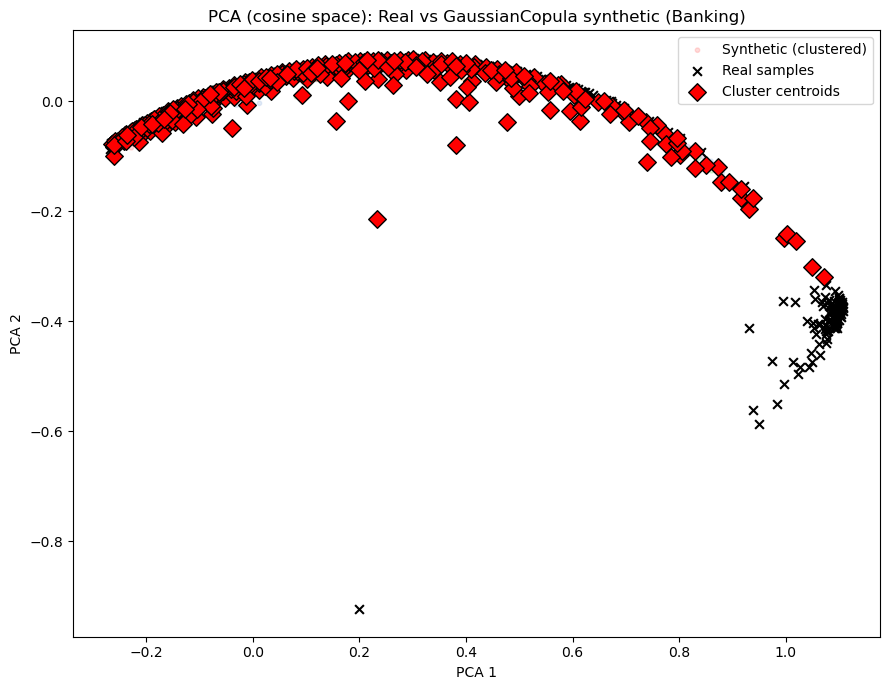


=== PCA + clustering for CTGAN (Banking dataset) ===


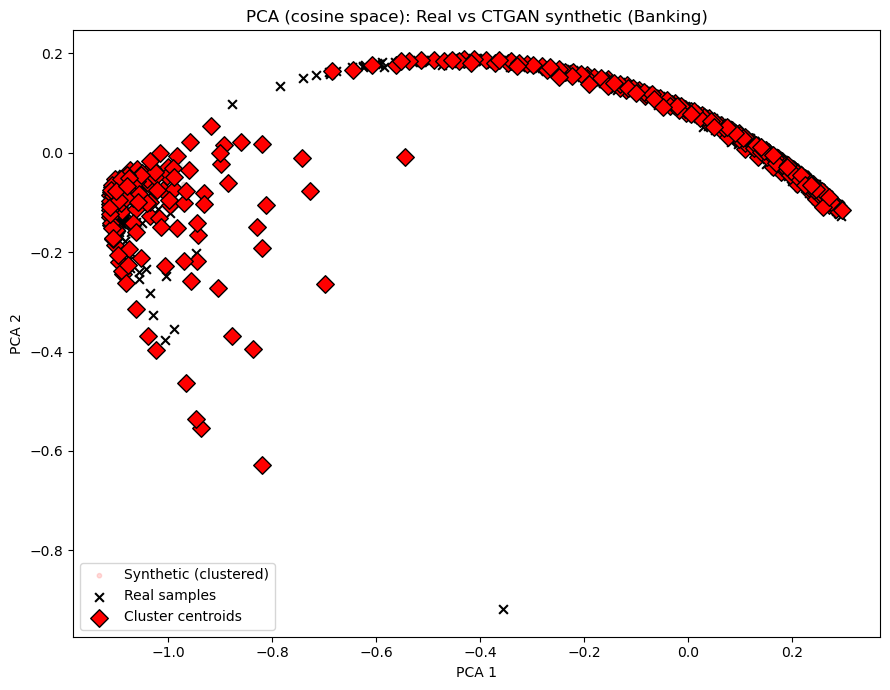


=== PCA + clustering for CopulaGAN (Banking dataset) ===


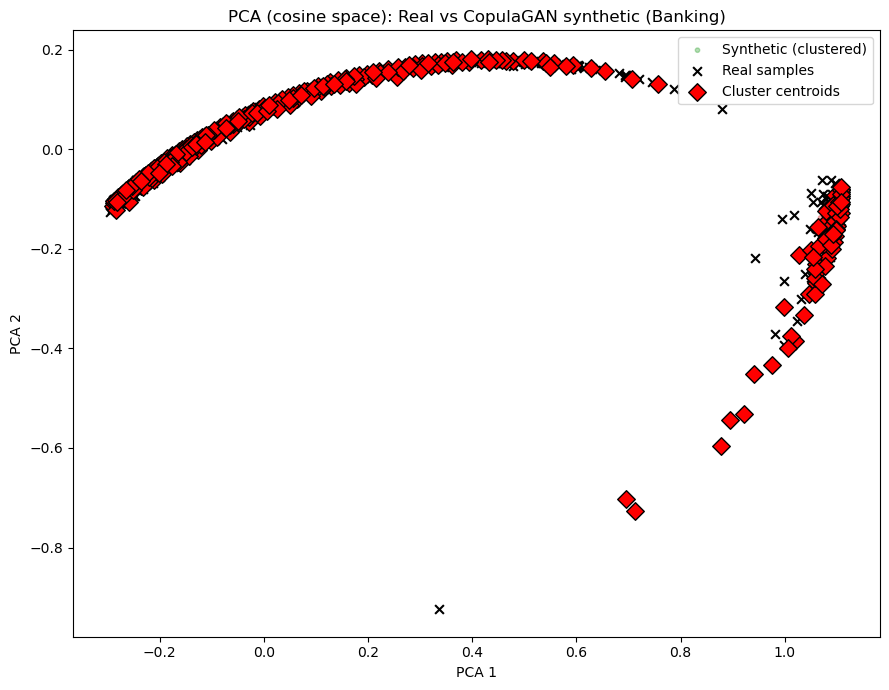


=== PCA + clustering for TVAE (Banking dataset) ===


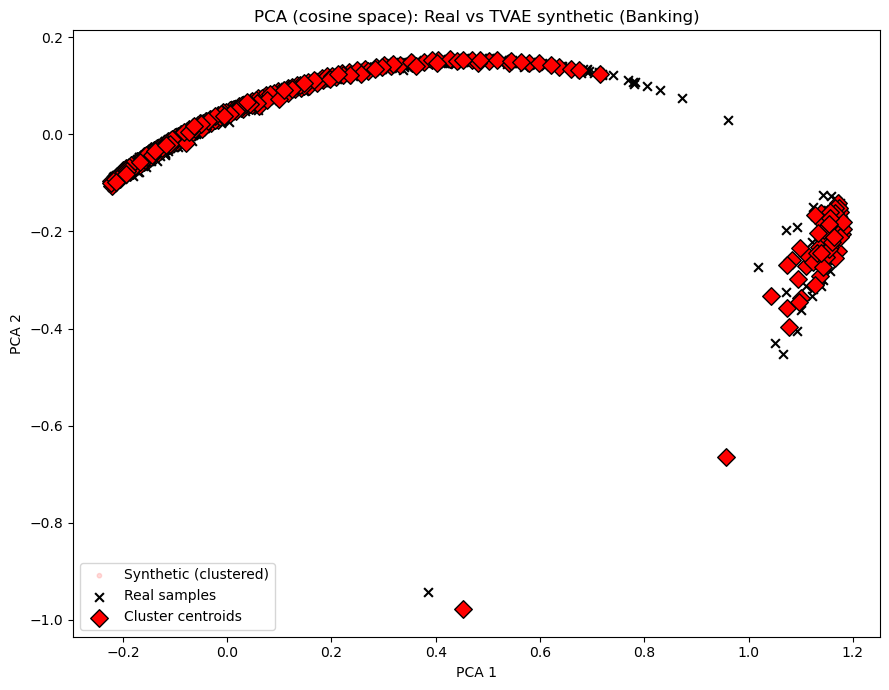

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Real banking dataset
# -------------------------------------------------
real_df = data

# Use ONLY numeric features (banking dataset)
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(num_cols)} numeric features:\n{num_cols}")

# -------------------------------------------------
# Synthetic datasets (already generated)
# -------------------------------------------------
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

# -------------------------------------------------
# Limits for visualization (important!)
# -------------------------------------------------
MAX_REAL = 3000        # real samples to plot
MAX_SYNTH = 5000       # synthetic samples to plot
N_CLUSTERS = 300       # centroids (do NOT use len(real_df))

for model_name, synth_df in synthetic_tables.items():
    print(f"\n=== PCA + clustering for {model_name} (Banking dataset) ===")

    # -------------------------------------------------
    # 1. Cluster synthetic & match real to centroids
    # -------------------------------------------------
    result = cluster_synthetic_and_match(
        real_df=real_df.iloc[:MAX_REAL],
        synth_df=synth_df.iloc[:MAX_SYNTH],
        num_cols=num_cols,
        n_clusters=N_CLUSTERS,
        random_state=42
    )

    centroid_assignments = result["centroid_assignments"]
    centroid_sims        = result["centroid_similarities"]
    centroids            = result["centroids"]
    synth_cluster_labels = result["cluster_labels"]

    # -------------------------------------------------
    # 2. Build cosine-normalized matrices
    # -------------------------------------------------
    X_real = normalize_rows(
        real_df[num_cols].iloc[:MAX_REAL].to_numpy(dtype=float)
    )
    X_synth = normalize_rows(
        synth_df[num_cols].iloc[:MAX_SYNTH].to_numpy(dtype=float)
    )
    centroids_norm = normalize_rows(centroids)

    n_real = X_real.shape[0]
    n_synth = X_synth.shape[0]

    # -------------------------------------------------
    # 3. PCA on combined space
    # -------------------------------------------------
    X_all = np.vstack([X_real, X_synth, centroids_norm])
    pca = PCA(n_components=2, random_state=42)
    X_all_2d = pca.fit_transform(X_all)

    # Split back
    X_real_2d = X_all_2d[:n_real]
    X_synth_2d = X_all_2d[n_real:n_real + n_synth]
    X_centroids_2d = X_all_2d[n_real + n_synth:]

    # -------------------------------------------------
    # 4. Plot
    # -------------------------------------------------
    plt.figure(figsize=(9, 7))

    # Synthetic samples (colored by cluster)
    plt.scatter(
        X_synth_2d[:, 0],
        X_synth_2d[:, 1],
        c=synth_cluster_labels[:MAX_SYNTH],
        cmap="tab20",
        alpha=0.35,
        s=10,
        label="Synthetic (clustered)"
    )

    # Real samples
    plt.scatter(
        X_real_2d[:, 0],
        X_real_2d[:, 1],
        marker="x",
        c="black",
        s=40,
        linewidths=1.5,
        label="Real samples"
    )

    # Centroids
    plt.scatter(
        X_centroids_2d[:, 0],
        X_centroids_2d[:, 1],
        marker="D",
        c="red",
        s=80,
        edgecolors="black",
        label="Cluster centroids"
    )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA (cosine space): Real vs {model_name} synthetic (Banking)")
    plt.legend()
    plt.tight_layout()
    plt.show()